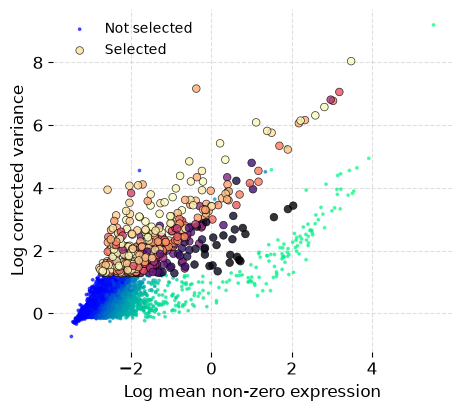

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    show_plot=True,
    hvg_key_name="hvgs_500",
)

In [2]:
for top_n, key in ((300, "hvgs_300"), (1000, "hvgs_1000")):
    ds.mark_hvgs(
        min_cells=20,
        top_n=top_n,
        show_plot=False,
        hvg_key_name=key,
    )
    ds.run_normalization(feat_key=key)
    ds.run_pca(dims=15)
    ds.build_embedding_initialization()
    ds.build_ann_index()
    ds.query_neighbors(k=11)
    ds.build_connectivity_map()
    ds.run_umap(
        n_epochs=150,
        spread=5,
        min_dist=1,
        parallel=True,
        label=f"{key}_UMAP",
    )
    ds.run_leiden_clustering(
        resolution=0.5,
        label=f"{key}_clusters",
    )

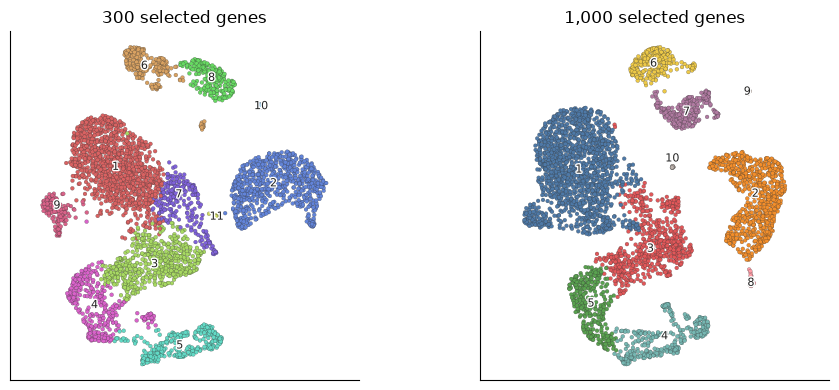

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, top_n in zip(axes, (300, 1000), strict=True):
    ds.plots.embedding(
        layout_key=f"RNA_hvgs_{top_n}_UMAP",
        color_by=f"RNA_hvgs_{top_n}_clusters",
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(f"{top_n:,} selected genes")
figure.tight_layout()
figure

In [4]:
pd.Series(
    {
        key: int(ds.RNA.feats.fetch_all(f"I__{key}").sum())
        for key in ("hvgs_300", "hvgs_1000")
    },
    name="selected genes",
)

hvgs_300      300
hvgs_1000    1000
Name: selected genes, dtype: int64